In [2]:
import pandas as pd
import numpy as np
fake = pd.read_csv("../data/Fake.csv")
real = pd.read_csv("../data/True.csv")
fake["label"] = 0
real["label"] = 1
df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)
print(df.shape)
print(df["label"].value_counts())
print(df.head())

(44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64
                                               title  \
0   Amy Schumer Is All Out Of F*cks To Give, Rele...   
1  BREAKING: Did Hillary’s Unsecured CLASSIFIED E...   
2   Here’s The Exact Moment CNN Got A Sitting Con...   
3  China unveils new leadership line-up with no c...   
4    New Zealand's 'first bloke' hooks into new role   

                                                text    subject  \
0  On Friday, Amy Schumer released a sketch that ...       News   
1  Will the State Department ever tell the truth ...  left-news   
2  CNN has been heavily criticized for its covera...       News   
3  BEIJING (Reuters) - China s ruling Communist P...  worldnews   
4  (Reuters) - New Zealand not only has its young...  worldnews   

                date  label  
0      June 25, 2016      0  
1        Aug 8, 2016      0  
2       June 7, 2016      0  
3  October 25, 2017       1  
4  October 20, 2017       1  


Preprocessing

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df["content"] = df["title"] + " " + df["text"]
df["content"] = df["content"].apply(clean_text)

print("Preprocessing done.")
print(df["content"].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sagni\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sagni\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sagni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sagni\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing done.
0    amy schumer fcks give release forbidden gun vi...
1    breaking hillary unsecured classified email ca...
2    here exact moment cnn got sitting congressman ...
3    china unveils new leadership lineup clear succ...
4    new zealand first bloke hook new role reuters ...
Name: content, dtype: str


In [5]:
!pip install gensim


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
import numpy as np



X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── TF-IDF ──────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape :", X_test_tfidf.shape)

# ── Word2Vec ─────────────────────────────────────────────
tokenized_train = [text.split() for text in X_train]
tokenized_test  = [text.split() for text in X_test]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

def get_w2v_vector(tokens, model, vector_size=100):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X_train_w2v = np.array([get_w2v_vector(t, w2v_model) for t in tokenized_train])
X_test_w2v  = np.array([get_w2v_vector(t, w2v_model) for t in tokenized_test])

print("Word2Vec Train shape:", X_train_w2v.shape)
print("Word2Vec Test shape :", X_test_w2v.shape)

TF-IDF Train shape: (35918, 5000)
TF-IDF Test shape : (8980, 5000)
Word2Vec Train shape: (35918, 100)
Word2Vec Test shape : (8980, 100)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf
import random
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

trained_models = {}

# ── Logistic Regression (TF-IDF) ─────────────────────────
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
trained_models["Logistic Regression"] = lr
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr.predict(X_test_tfidf)) * 100, "%")

# ── Naive Bayes (TF-IDF) ─────────────────────────────────
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
trained_models["Naive Bayes"] = nb
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb.predict(X_test_tfidf)) * 100, "%")

# ── Random Forest (TF-IDF) ───────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
trained_models["Random Forest"] = rf
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf.predict(X_test_tfidf)) * 100, "%")

# ── LSTM (Keras Tokenizer + Padding) ─────────────────────
MAX_WORDS = 5000
MAX_LEN   = 300

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_test_seq  = keras_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"LSTM Accuracy: {lstm_acc * 100:.2f}%")

Logistic Regression Accuracy: 98.97550111358575 %
Naive Bayes Accuracy: 94.68819599109132 %
Random Forest Accuracy: 99.84409799554565 %


C:\MyProjects\fake-news-detector\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.6426 - loss: 0.6075 - val_accuracy: 0.8892 - val_loss: 0.3657
Epoch 2/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.9012 - loss: 0.3266 - val_accuracy: 0.9129 - val_loss: 0.2931
Epoch 3/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.8945 - loss: 0.3164 - val_accuracy: 0.9073 - val_loss: 0.2890
Epoch 4/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 47s 94ms/step - accuracy: 0.9209 - loss: 0.2473 - val_accuracy: 0.9552 - val_loss: 0.1591
Epoch 5/5
506/506 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.9614 - loss: 0.1276 - val_accuracy: 0.9727 - val_loss: 0.0971
LSTM Accuracy: 97.35%


        MODEL COMPARISON TABLE
281/281 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
                 Model Accuracy Precision  Recall F1-Score
1  Logistic Regression   98.98%    99.00%  98.86%   98.93%
2          Naive Bayes   94.69%    95.05%  93.78%   94.41%
3        Random Forest   99.84%    99.81%  99.86%   99.84%
4                 LSTM   97.35%    97.03%  97.44%   97.24%
Best Model: Random Forest


  DETAILED EVALUATION — RANDOM FOREST (Best Model)

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4684
        Real       1.00      1.00      1.00      4296

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

AUC-ROC Score: 0.9999


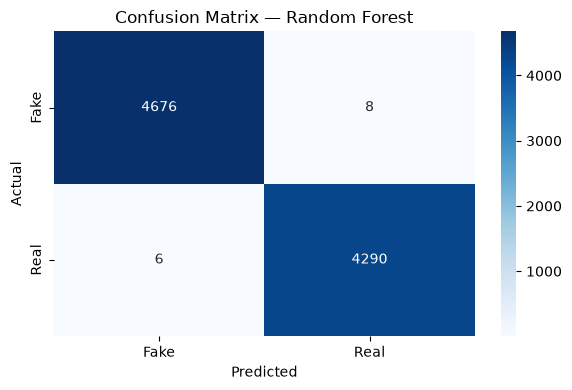

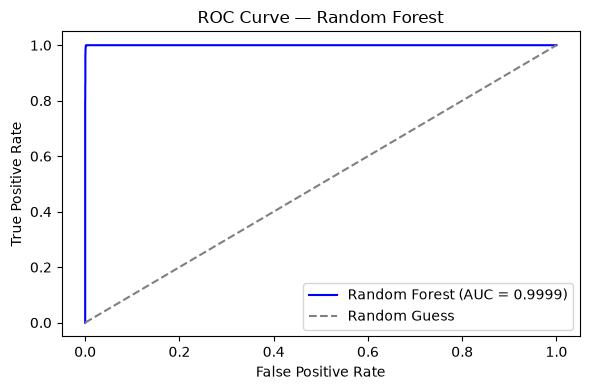



       DETAILED EVALUATION — LSTM

Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.97      0.97      4684
        Real       0.97      0.97      0.97      4296

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



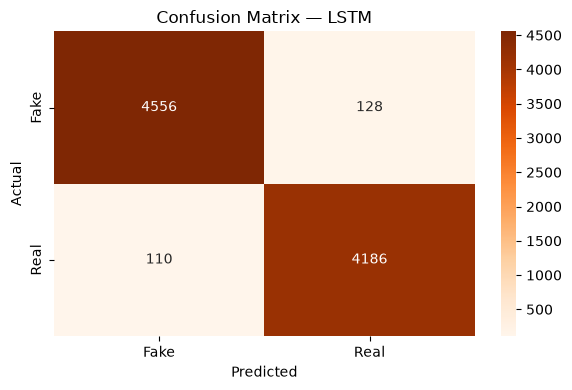

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=" * 55)
print("        MODEL COMPARISON TABLE")
print("=" * 55)

results = []

for name, model in trained_models.items():
    pred = model.predict(X_test_tfidf)
    acc  = accuracy_score(y_test, pred)
    from sklearn.metrics import precision_score, recall_score, f1_score
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    results.append({
        "Model":     name,
        "Accuracy":  f"{acc * 100:.2f}%",
        "Precision": f"{prec * 100:.2f}%",
        "Recall":    f"{rec * 100:.2f}%",
        "F1-Score":  f"{f1 * 100:.2f}%"
    })

lstm_preds_prob = lstm_model.predict(X_test_pad).flatten()
lstm_preds      = (lstm_preds_prob >= 0.5).astype(int)
from sklearn.metrics import precision_score, recall_score, f1_score
acc  = accuracy_score(y_test, lstm_preds)
prec = precision_score(y_test, lstm_preds)
rec  = recall_score(y_test, lstm_preds)
f1   = f1_score(y_test, lstm_preds)
results.append({
    "Model":     "LSTM",
    "Accuracy":  f"{acc * 100:.2f}%",
    "Precision": f"{prec * 100:.2f}%",
    "Recall":    f"{rec * 100:.2f}%",
    "F1-Score":  f"{f1 * 100:.2f}%"
})

comparison_df = pd.DataFrame(results)
comparison_df.index = range(1, len(comparison_df) + 1)
print(comparison_df.to_string())
print("=" * 55)
print("Best Model: Random Forest")
print("=" * 55)

print("\n")
print("=" * 55)
print("  DETAILED EVALUATION — RANDOM FOREST (Best Model)")
print("=" * 55)

y_pred = trained_models["Random Forest"].predict(X_test_tfidf)
y_prob = trained_models["Random Forest"].predict_proba(X_test_tfidf)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

print("\n")
print("=" * 55)
print("       DETAILED EVALUATION — LSTM")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, lstm_preds, target_names=["Fake", "Real"]))

cm_lstm = confusion_matrix(y_test, lstm_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.title("Confusion Matrix — LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png")
plt.show()

In [ ]:
 import joblib

# ================== SAVE SKLEARN MODELS ==================
joblib.dump(trained_models["Random Forest"], "rf_model.pkl")
joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(keras_tokenizer, "tokenizer.pkl")

# ================== SAVE LSTM MODEL ==================
lstm_model.save("lstm_model.keras")

print("All models saved successfully.")

In [9]:
import pandas as pd

test_df = pd.DataFrame({"content": X_test, "actual": y_test})

print("=== 5 FAKE news samples ===")
fake_samples = test_df[test_df["actual"] == 0]["content"].head(5)
for i, text in enumerate(fake_samples):
    print(f"\nSample {i+1}:", text[:200])

print("\n=== 5 REAL news samples ===")
real_samples = test_df[test_df["actual"] == 1]["content"].head(5)
for i, text in enumerate(real_samples):
    print(f"\nSample {i+1}:", text[:200])

=== 5 FAKE news samples ===

Sample 1: video show trump backing racial violence shocking way havent seen donald trump moved step closer officially sanctioning racial violence committed name telling multiple medium outlet would take look pa

Sample 2: watch yr old woman voted first time life trump first time voter democrat minority woman elderly youth jumping aboard trump train much enthusiasm crosssection america even possible trump beaten strong 

Sample 3: msnbc propagandist word trump modern day swastikablames trump mosque arson video unbelievable socalled expert get spout hatred towards president trump regular basis via msnbc village idiot connects mo

Sample 4: liberal journalist go border get shocking answer wall mexico video liberal reporter esquire got dose reality went along border asked anyone saw weigh need done border stop illegals got surprising resu

Sample 5: chrissy teigen told fox news fck fck best way possible tweet hoo boy chrissy teigen like fox news united airline 